In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IndentationError: unexpected indent (dataTools.py, line 1)

In [1]:
import os, sys, json
sys.path.insert(0, "/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/src/calib")

from utils import LogFile
from constructor import Selection

pathToInfo = f"/Users/jcapo/cernbox/DUNE-IFIC/Software/rtd/src/calib/utils/logs/systems.json"

with open(pathToInfo, 'r') as file:
    info = json.load(file)
log_file = LogFile()
s1 = Selection(log_file=log_file, **info["LN23TGRAD"]["sets"]["first_round"]["TGrad-1"])
s1.compute_calconst(ref="40525")

s2 = Selection(log_file=log_file, **info["LN23TGRAD"]["sets"]["first_round"]["TGrad-2"])
s2.compute_calconst(ref="39629")

s3 = Selection(log_file=log_file, **info["LN23TGRAD"]["sets"]["first_round"]["TGrad-3"])
s3.compute_calconst(ref="40533")

s4 = Selection(log_file=log_file, **info["LN23TGRAD"]["sets"]["first_round"]["TGrad-4"])
s4.compute_calconst(ref="39666")

s5 = Selection(log_file=log_file, **info["LN23TGRAD"]["sets"]["second_round"])
s5.compute_calconst(ref="39666")

Initializing constructor module...
Reading data file: /Users/jcapo/cernbox/RTDdata/Data/TGrad_Calibs/TGrad2_1/30012023_ln2_r44123_r44124_TGrad1_1.txt 

Data in data file:            0         1         2         3         4         5         6   \
0  30/01/2023  13:19:47  77.38596  77.37565  77.35651  77.38038  77.42476   
1  30/01/2023  13:19:50  77.38588  77.37537  77.35654  77.38088  77.42518   
2  30/01/2023  13:19:54  77.38593  77.37547  77.35681  77.38049  77.42528   
3  30/01/2023  13:19:58  77.38618  77.37556  77.35695  77.38059  77.42497   
4  30/01/2023  13:20:01  77.38620  77.37548  77.35688  77.38116  77.42522   

         7         8         9         10        11        12        13  \
0  77.39822  77.40734  77.42627  77.40008  77.36890  77.37980  77.38920   
1  77.39802  77.40712  77.42608  77.39971  77.36842  77.38005  77.38893   
2  77.39792  77.40715  77.42590  77.40045  77.36807  77.37993  77.38939   
3  77.39773  77.40700  77.42606  77.39990  77.36845  77.37976  77.

KeyError: '40525'

In [2]:
ga_std_1_1_path = "/Users/jcapo/cernbox/RTDdata/Data/GasArray-PrM-PUMP/GasArray/GasArray_STD_1/20220930_ln2_r1G13_r1G14_1G1-1G12_1.txt"
ga_std_1_2_path = "/Users/jcapo/cernbox/RTDdata/Data/GasArray-PrM-PUMP/GasArray/GasArray_STD_1/20220930_ln2_r1G13_r1G14_1G1-1G12_2.txt"

ga_std_2_1_path = "/Users/jcapo/cernbox/RTDdata/Data/GasArray-PrM-PUMP/GasArray/GasArray_STD_2/20220930_ln2_r2G13_r2G14_2G1-2G12_1.txt"
ga_std_2_2_path = "/Users/jcapo/cernbox/RTDdata/Data/GasArray-PrM-PUMP/GasArray/GasArray_STD_2/20220930_ln2_r2G13_r2G14_2G1-2G12_2.txt"

In [10]:
ga_std_1_1 = pd.read_csv(ga_std_1_1_path, sep="\t", comment="#", header=None, names=["Date", "Time", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14"])
ga_std_1_2 = pd.read_csv(ga_std_1_2_path, sep="\t", comment="#", header=None, names=["Date", "Time", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14"])
ga_std_2_1 = pd.read_csv(ga_std_2_1_path, sep="\t", comment="#", header=None, names=["Date", "Time", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28"])
ga_std_2_2 = pd.read_csv(ga_std_2_2_path, sep="\t", comment="#", header=None, names=["Date", "Time", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28"])

def add_timestamp_column(df):
    df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)
    return df

# Example usage:
ga_std_1_1 = add_timestamp_column(ga_std_1_1)
ga_std_1_2 = add_timestamp_column(ga_std_1_2)
ga_std_2_1 = add_timestamp_column(ga_std_2_1)
ga_std_2_2 = add_timestamp_column(ga_std_2_2)

ga_std_1_1 = ga_std_1_1.set_index('Timestamp')
ga_std_1_2 = ga_std_1_2.set_index('Timestamp')
ga_std_2_1 = ga_std_2_1.set_index('Timestamp')
ga_std_2_2 = ga_std_2_2.set_index('Timestamp')

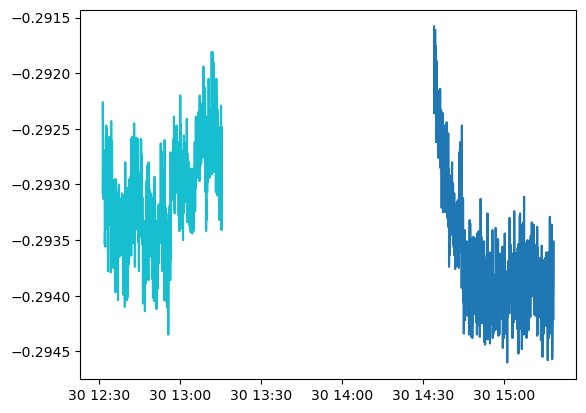

In [13]:
plt.plot(ga_std_1_1.index, ga_std_1_1["1"] - ga_std_1_1["2"], label="GA1-1", color="tab:cyan")
plt.plot(ga_std_1_2.index, ga_std_1_2["1"] - ga_std_1_2["2"], label="GA1-2", color="tab:blue")